Libraries Imported Successfully
Dataset Loaded Successfully

Cleaned Column Names:
['id', 'title', 'user_id', 'profilename', 'review_time', 'review_text']

Dataset Shape:
(300000, 6)

First 5 Rows:


,id,title,user_id,profilename,review_time,review_text
0,B000QBHBVY,The Greatest Generation,A2CO8P4FJ1CY8N,"Bluerigged ""jsnapper""",949104000,One thing is certain - Tom Brokaw is no author...
1,B0006ES1WO,Dealing with dragons (The Enchanted Forest chr...,NaN,NaN,951523200,When I first read this book a couple years bac...
2,0782129935,Anarchy Online: Sybex Official Strategies and ...,A2I4ZBF1HSIO7V,Stephanie J Davey,998006400,This guide is missing some essential details t...
3,0865304572,If You Don't Feed the Teachers They Eat the St...,A1RZII8RKZCNU6,Rebecca A. Rose,1142208000,"thanks for a wonderful job, the book and the s..."
4,1593351100,Blood of the Fold (Sword of Truth Series),NaN,NaN,898646400,Blood of the fold did not make me dissapointed...



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           300000 non-null  str  
 1   title        299998 non-null  str  
 2   user_id      242001 non-null  str  
 3   profilename  241995 non-null  str  
 4   review_time  300000 non-null  int64
 5   review_text  299999 non-null  str  
dtypes: int64(1), str(5)
memory usage: 269.5 MB

Text Column Null Values Handled Successfully

Memory Usage Per Column:
Index                132
id               5400000
title           13699201
user_id          5761327
profilename      6161706
review_time      2400000
review_text    249073774
dtype: int64

Total Memory Usage: 269.41 MB

Missing Values:
id                 0
title              0
user_id        57999
profilename        0
review_time        0
review_text        0
dtype: int64

Missing Value Percentage:
user_id        19.333
id     

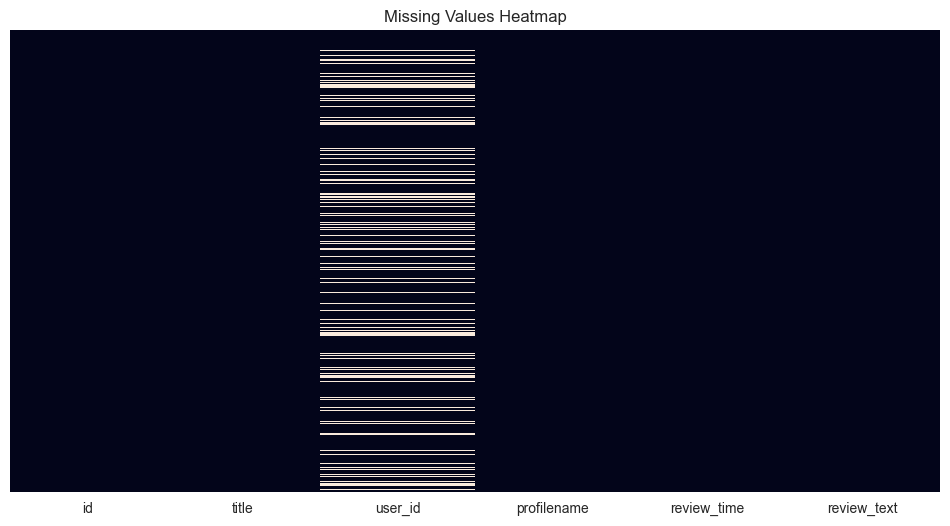


Duplicate Rows: 1163

Dataset Shape After Removing Duplicates:
(298837, 6)


In [1]:
# ============================================================
# AMAZON BOOK REVIEWS CLUSTERING PROJECT
# NOTEBOOK: 01_data_understanding.ipynb
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# plotting style
sns.set_style("whitegrid")

print("Libraries Imported Successfully")


# ============================================================
# STEP 2 — LOAD DATASET
# ============================================================

DATA_PATH = "../data/raw/amazon_book_reviews.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")


# ============================================================
# STEP 3 — CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())


# ============================================================
# STEP 4 — BASIC DATA INSPECTION
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())


# ============================================================
# STEP 5 — DATASET INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()


# ============================================================
# STEP 6 — HANDLE NULL VALUES IN TEXT COLUMNS
# ============================================================

text_columns = [
    "title",
    "profilename",
    "review_text"
]

for col in text_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .fillna("")
            .astype(str)
        )

print("\nText Column Null Values Handled Successfully")


# ============================================================
# STEP 7 — MEMORY USAGE ANALYSIS
# ============================================================

memory_usage = df.memory_usage(deep=True)

print("\nMemory Usage Per Column:")
print(memory_usage)

total_memory = memory_usage.sum() / 1024**2

print(f"\nTotal Memory Usage: {total_memory:.2f} MB")


# ============================================================
# STEP 8 — MISSING VALUE ANALYSIS
# ============================================================

print("\nMissing Values:")

missing_values = df.isnull().sum()

print(missing_values)


# ============================================================
# STEP 9 — MISSING VALUE PERCENTAGE
# ============================================================

print("\nMissing Value Percentage:")

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(
    missing_percentage.sort_values(
        ascending=False
    )
)


# ============================================================
# STEP 10 — MISSING VALUE HEATMAP
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()


# ============================================================
# STEP 11 — DUPLICATE ANALYSIS
# ============================================================

duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows: {duplicates}")


# ============================================================
# STEP 12 — REMOVE DUPLICATES
# ============================================================

df.drop_duplicates(inplace=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


In [3]:
# ============================================================
# STEP 13 — DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics:")

display(df.describe())


Descriptive Statistics:


,review_time
count,2.988370e+05
mean,1.131583e+09
std,1.490339e+08
min,-1.000000e+00
25%,9.995616e+08
50%,1.127347e+09
75%,1.267747e+09
max,1.362269e+09



Review Length Feature Created

Review Length Statistics:


count    298837.000000
mean        821.353945
std         971.662600
min           0.000000
25%         262.000000
50%         515.000000
75%        1006.000000
max       32303.000000
Name: review_length, dtype: float64

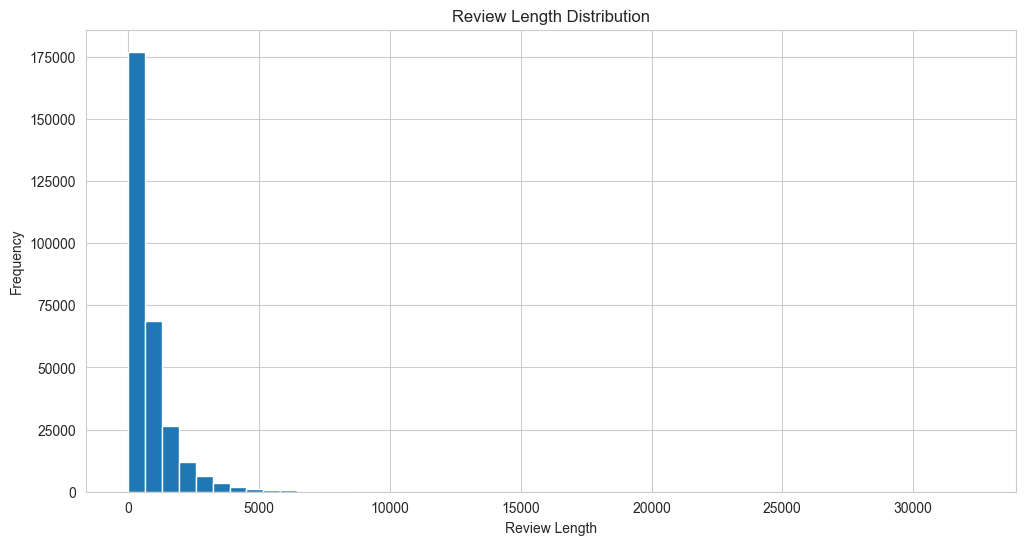

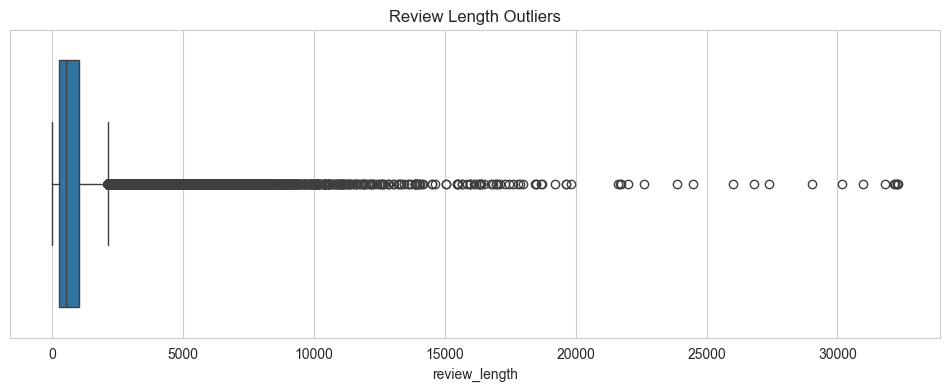


Combined Text Column Created


,title,review_text,combined_text
0,The Greatest Generation,One thing is certain - Tom Brokaw is no author...,The Greatest Generation One thing is certain -...
1,Dealing with dragons (The Enchanted Forest chr...,When I first read this book a couple years bac...,Dealing with dragons (The Enchanted Forest chr...
2,Anarchy Online: Sybex Official Strategies and ...,This guide is missing some essential details t...,Anarchy Online: Sybex Official Strategies and ...
3,If You Don't Feed the Teachers They Eat the St...,"thanks for a wonderful job, the book and the s...",If You Don't Feed the Teachers They Eat the St...
4,Blood of the Fold (Sword of Truth Series),Blood of the fold did not make me dissapointed...,Blood of the Fold (Sword of Truth Series) Bloo...



Generating Word Frequency Analysis...

Top 20 Most Common Words:
[('the', 2135533), ('and', 1278202), ('of', 1249039), ('to', 1109934), ('a', 1063758), ('is', 776633), ('I', 685668), ('in', 654226), ('that', 503886), ('this', 431215), ('book', 409019), ('it', 391328), ('for', 352558), ('was', 313281), ('with', 294877), ('as', 282130), ('you', 232626), ('are', 232265), ('The', 228654), ('on', 218980)]


,Word,Frequency
0,the,2135533
1,and,1278202
2,of,1249039
3,to,1109934
4,a,1063758
5,is,776633
6,I,685668
7,in,654226
8,that,503886
9,this,431215


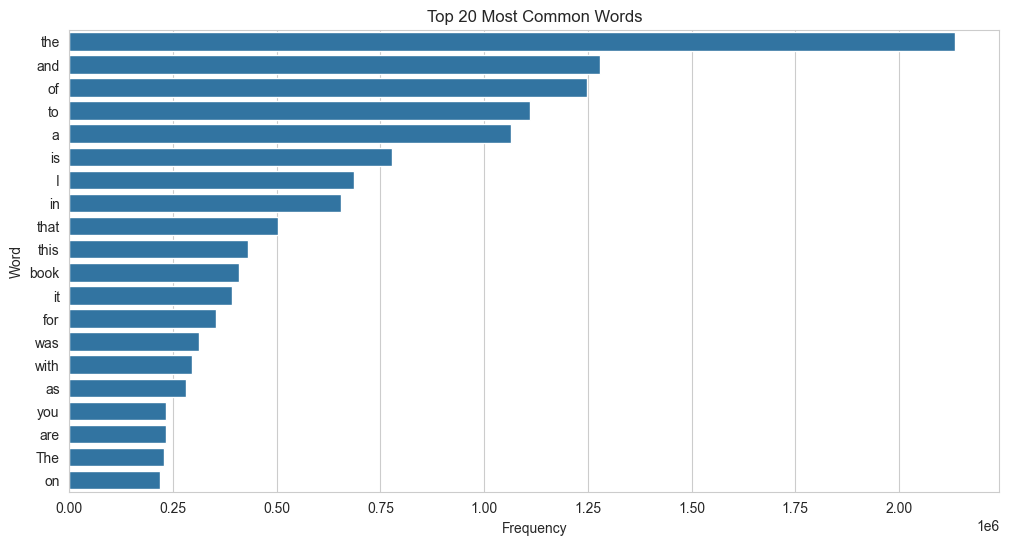


Review Datetime Feature Created

Review Year Feature Created


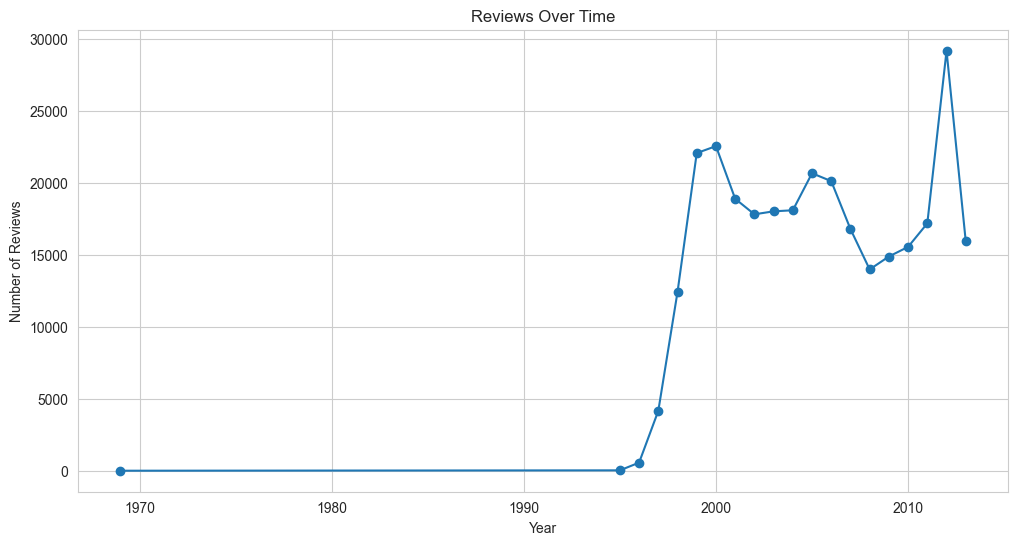


Top 10 Reviewers:
profilename
                                      57609
Midwest Book Review                     565
A Customer                              530
E. A Solinas "ea_solinas"               353
Harriet Klausner                        328
Blue Tyson "- Research Finished"        189
Shalom Freedman "Shalom Freedman"       186
John                                    158
Donald Mitchell "Jesus Loves You!"      156
Avid Reader                             147
Name: count, dtype: int64


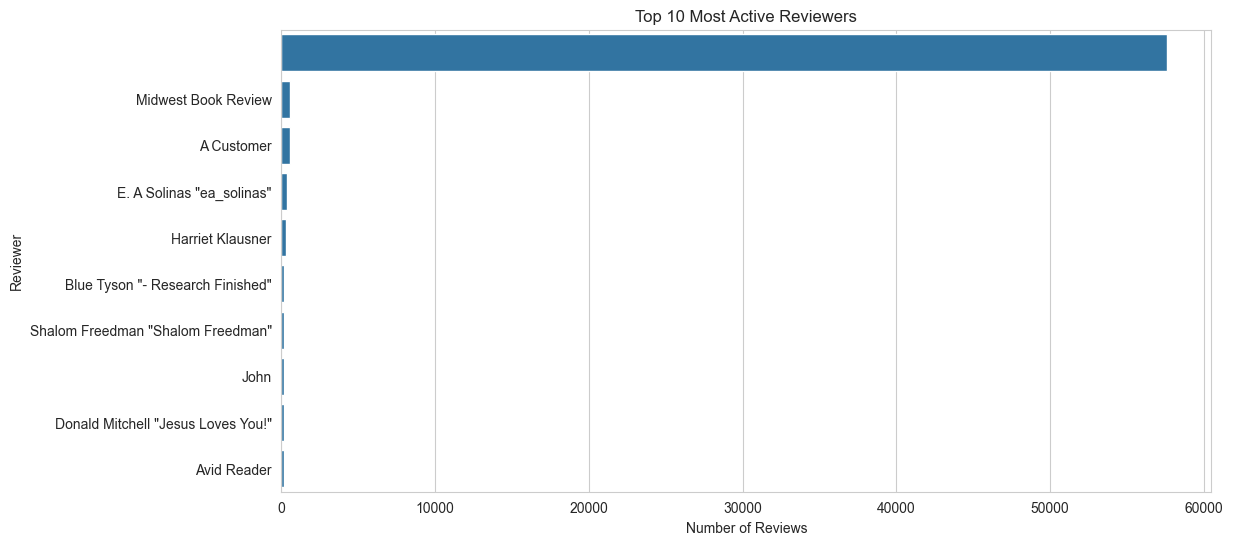


Empty Reviews: 1

Unique Users: 172446

Unique Book Titles: 37424

Remaining Missing Values:


id                     0
title                  0
user_id            57603
profilename            0
review_time            0
review_text            0
review_length          0
combined_text          0
review_datetime        0
review_year            0
dtype: int64


Processed Dataset Saved Successfully

Final Dataset Shape:
(298837, 10)

Final Dataset Preview:


,id,title,user_id,profilename,review_time,review_text,review_length,combined_text,review_datetime,review_year
0,B000QBHBVY,The Greatest Generation,A2CO8P4FJ1CY8N,"Bluerigged ""jsnapper""",949104000,One thing is certain - Tom Brokaw is no author...,2332,The Greatest Generation One thing is certain -...,2000-01-29,2000
1,B0006ES1WO,Dealing with dragons (The Enchanted Forest chr...,NaN,,951523200,When I first read this book a couple years bac...,337,Dealing with dragons (The Enchanted Forest chr...,2000-02-26,2000
2,0782129935,Anarchy Online: Sybex Official Strategies and ...,A2I4ZBF1HSIO7V,Stephanie J Davey,998006400,This guide is missing some essential details t...,489,Anarchy Online: Sybex Official Strategies and ...,2001-08-17,2001
3,0865304572,If You Don't Feed the Teachers They Eat the St...,A1RZII8RKZCNU6,Rebecca A. Rose,1142208000,"thanks for a wonderful job, the book and the s...",76,If You Don't Feed the Teachers They Eat the St...,2006-03-13,2006
4,1593351100,Blood of the Fold (Sword of Truth Series),NaN,,898646400,Blood of the fold did not make me dissapointed...,512,Blood of the Fold (Sword of Truth Series) Bloo...,1998-06-24,1998



NOTEBOOK 01 COMPLETED SUCCESSFULLY

Tasks Completed:
1. Dataset Loaded
2. Column Cleaning
3. Shape Analysis
4. Datatype Analysis
5. Missing Value Analysis
6. Duplicate Analysis
7. Review Length Analysis
8. Word Frequency Analysis
9. Combined Text Feature
10. Review Time Analysis
11. Top Reviewer Analysis
12. NLP Readiness Checks
13. Visualizations
14. Processed Dataset Saved

Ready for Notebook 02 — Data Preprocessing


In [5]:
# ============================================================
# STEP 14 — CREATE REVIEW LENGTH FEATURE
# ============================================================

df["review_length"] = (
    df["review_text"]
    .apply(lambda x: len(str(x)))
)

print("\nReview Length Feature Created")


# ============================================================
# STEP 15 — REVIEW LENGTH STATISTICS
# ============================================================

print("\nReview Length Statistics:")

display(
    df["review_length"].describe()
)


# ============================================================
# STEP 16 — REVIEW LENGTH HISTOGRAM
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")

plt.xlabel("Review Length")

plt.ylabel("Frequency")

plt.show()


# ============================================================
# STEP 17 — REVIEW LENGTH BOXPLOT
# ============================================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["review_length"]
)

plt.title("Review Length Outliers")

plt.show()


# ============================================================
# STEP 18 — CREATE COMBINED TEXT COLUMN
# ============================================================

df["combined_text"] = (
    df["title"]
    + " "
    + df["review_text"]
)

print("\nCombined Text Column Created")


# ============================================================
# STEP 19 — CHECK COMBINED TEXT
# ============================================================

display(
    df[[
        "title",
        "review_text",
        "combined_text"
    ]].head()
)


# ============================================================
# STEP 20 — WORD FREQUENCY ANALYSIS
# ============================================================

print("\nGenerating Word Frequency Analysis...")

all_words = " ".join(
    df["review_text"]
).split()

word_freq = Counter(all_words)

print("\nTop 20 Most Common Words:")

print(
    word_freq.most_common(20)
)


# ============================================================
# STEP 21 — WORD FREQUENCY DATAFRAME
# ============================================================

common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)


# ============================================================
# STEP 22 — WORD FREQUENCY VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_words
)

plt.title("Top 20 Most Common Words")

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.show()


# ============================================================
# STEP 23 — CONVERT REVIEW TIME TO DATETIME
# ============================================================

df["review_datetime"] = pd.to_datetime(
    df["review_time"],
    unit="s",
    errors="coerce"
)

print("\nReview Datetime Feature Created")


# ============================================================
# STEP 24 — CREATE REVIEW YEAR FEATURE
# ============================================================

df["review_year"] = (
    df["review_datetime"]
    .dt.year
)

print("\nReview Year Feature Created")


# ============================================================
# STEP 25 — YEARLY REVIEW DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

df["review_year"] \
    .value_counts() \
    .sort_index() \
    .plot(
        kind="line",
        marker="o"
    )

plt.title("Reviews Over Time")

plt.xlabel("Year")

plt.ylabel("Number of Reviews")

plt.show()


# ============================================================
# STEP 26 — TOP REVIEWERS ANALYSIS
# ============================================================

top_reviewers = (
    df["profilename"]
    .value_counts()
    .head(10)
)

print("\nTop 10 Reviewers:")

print(top_reviewers)


# ============================================================
# STEP 27 — TOP REVIEWERS VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Most Active Reviewers")

plt.xlabel("Number of Reviews")

plt.ylabel("Reviewer")

plt.show()


# ============================================================
# STEP 28 — CHECK EMPTY REVIEWS
# ============================================================

empty_reviews = (
    df["review_text"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"\nEmpty Reviews: {empty_reviews}")


# ============================================================
# STEP 29 — CHECK UNIQUE USERS
# ============================================================

unique_users = df["user_id"].nunique()

print(f"\nUnique Users: {unique_users}")


# ============================================================
# STEP 30 — CHECK UNIQUE BOOK TITLES
# ============================================================

unique_titles = df["title"].nunique()

print(f"\nUnique Book Titles: {unique_titles}")


# ============================================================
# STEP 31 — FINAL NULL VALUE CHECK
# ============================================================

print("\nRemaining Missing Values:")

display(
    df.isnull().sum()
)


# ============================================================
# STEP 32 — SAVE PROCESSED OUTPUT
# ============================================================

OUTPUT_PATH = (
    "../data/processed/"
    "data_understanding_output.csv"
)

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nProcessed Dataset Saved Successfully")


# ============================================================
# STEP 33 — FINAL DATASET CHECK
# ============================================================

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Preview:")

display(df.head())


# ============================================================
# STEP 34 — PROJECT CHECKPOINT SUMMARY
# ============================================================

print("\n================================================")
print("NOTEBOOK 01 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nTasks Completed:")

print("1. Dataset Loaded")
print("2. Column Cleaning")
print("3. Shape Analysis")
print("4. Datatype Analysis")
print("5. Missing Value Analysis")
print("6. Duplicate Analysis")
print("7. Review Length Analysis")
print("8. Word Frequency Analysis")
print("9. Combined Text Feature")
print("10. Review Time Analysis")
print("11. Top Reviewer Analysis")
print("12. NLP Readiness Checks")
print("13. Visualizations")
print("14. Processed Dataset Saved")

print("\nReady for Notebook 02 — Data Preprocessing")